In [15]:
!pip install pandas scikit-learn

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
df = pd.read_csv("Crop_recommendation.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [18]:
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [19]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



Model Accuracy: 99.32 %


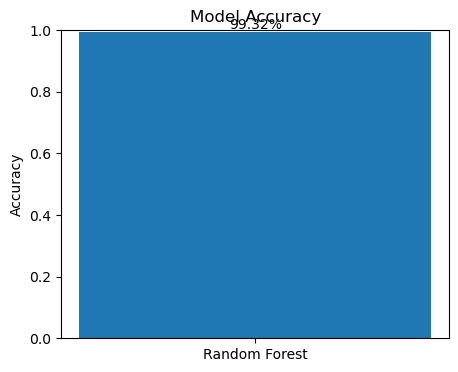

In [20]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", round(accuracy*100,2), "%")
plt.figure(figsize=(5,4))

plt.bar(['Random Forest'], [accuracy])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")

plt.text(0, accuracy+0.01, str(round(accuracy*100,2))+"%", ha='center')

plt.ylim(0,1)

plt.show()


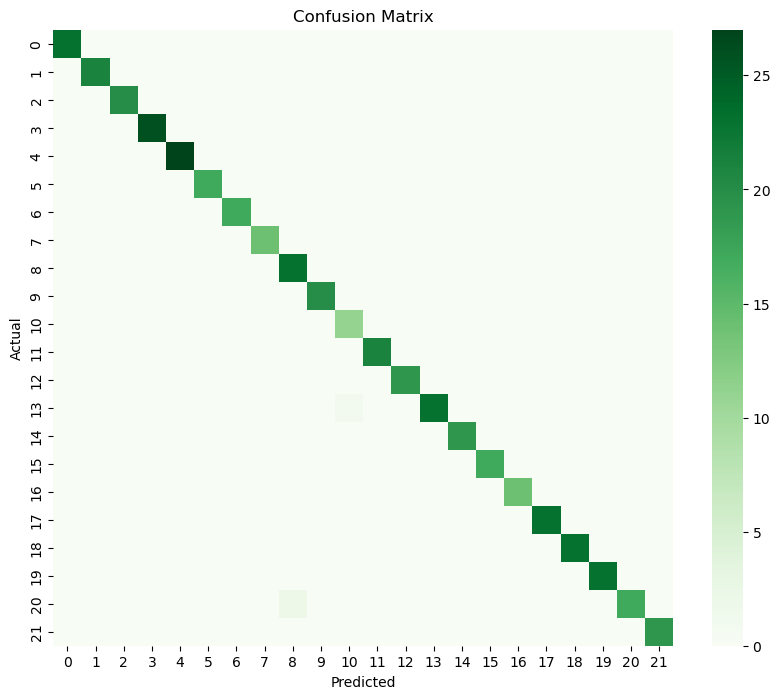

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm, cmap="Greens")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

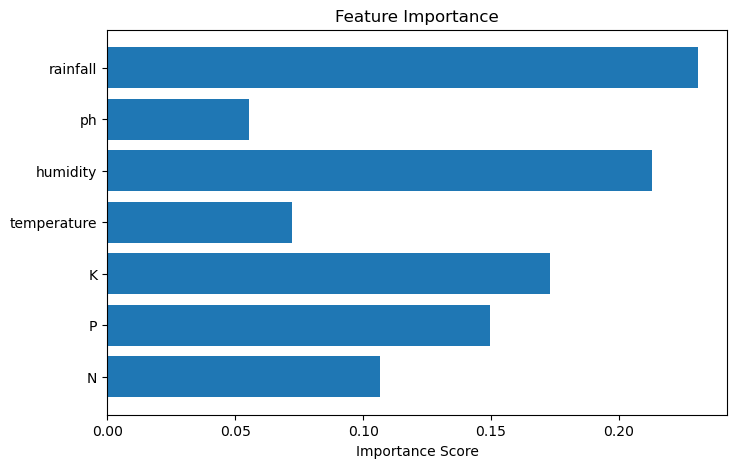

In [22]:
features = ['N','P','K','temperature','humidity','ph','rainfall']

importance = model.feature_importances_

plt.figure(figsize=(8,5))

plt.barh(features, importance)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()

In [23]:
def recommend_crop():

    N = int(input("Enter Nitrogen value: "))
    P = int(input("Enter Phosphorus value: "))
    K = int(input("Enter Potassium value: "))
    temperature = float(input("Enter Temperature: "))
    humidity = float(input("Enter Humidity: "))
    ph = float(input("Enter pH value: "))
    rainfall = float(input("Enter Rainfall: "))

    prediction = model.predict([[N,P,K,temperature,humidity,ph,rainfall]])

    print("\n-----------------------------------")
    print(" Recommended Crop:", prediction[0])
    print("-----------------------------------")

In [24]:
recommend_crop()

Enter Nitrogen value:  56
Enter Phosphorus value:  65
Enter Potassium value:  65
Enter Temperature:  32
Enter Humidity:  98
Enter pH value:  6.6
Enter Rainfall:  54



-----------------------------------
 Recommended Crop: papaya
-----------------------------------


C:\Users\darsh\anaconda3\New folder\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
